In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
df = pd.read_csv("data_clean.csv", sep=";")

df.columns = df.columns.str.strip().str.lower()

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")
df = df.reset_index(drop=True)

df.head()

,date,close,open,high,low,volume,variation,return,volatility,lag1,lag2,vol_lag1,vol_lag2,ret_abs,ret_sq,ma5,ma20,std5,std20
0,2021-01-07,921.52,915.67,924.79,915.67,NaN,0.64,0.006368,0.011955,-0.004196,-0.010214,NaN,NaN,0.006368,0.000041,922.090,925.3745,0.007626,0.011955
1,2021-01-08,919.60,921.52,924.31,918.90,NaN,-0.21,-0.002086,0.011970,0.006368,-0.004196,0.011955,NaN,0.002086,0.000004,921.054,925.9795,0.006724,0.011970
2,2021-01-12,923.89,919.60,923.89,916.78,NaN,0.47,0.004654,0.010474,-0.002086,0.006368,0.011970,0.011955,0.004654,0.000022,920.040,925.6135,0.006755,0.010474
3,2021-01-13,919.89,923.89,925.45,918.95,NaN,-0.43,-0.004339,0.010480,0.004654,-0.002086,0.010474,0.011970,0.004339,0.000019,920.114,925.2355,0.005074,0.010480
4,2021-01-14,926.07,919.89,926.43,919.89,NaN,0.67,0.006696,0.010576,-0.004339,0.004654,0.010480,0.010474,0.006696,0.000045,922.194,925.0285,0.005117,0.010576


In [7]:
feature_cols = [
    "lag1",
    "lag2",
    "vol_lag1",
    "vol_lag2",
    "ret_abs",
    "ret_sq",
    "ma5",
    "ma20",
    "std5",
    "std20"
]

target_col = "volatility"

df_model = df.dropna(subset=feature_cols + [target_col])

X = df_model[feature_cols]
y = df_model[target_col]

print("Taille finale :", df_model.shape)

Taille finale : (1317, 19)


In [8]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train : (1053, 10)
X_test : (264, 10)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [7]:
def quantile_loss(q):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
    return loss

In [8]:
def build_qnn(input_dim, q):
    model = Sequential()
    
    model.add(Input(shape=(input_dim,)))
    
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.2))
    
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.2))
    
    model.add(Dense(1, activation="softplus"))
    
    model.compile(
        optimizer="adam",
        loss=quantile_loss(q)
    )
    
    return model

In [9]:
quantiles = [0.1, 0.5, 0.9]

models = {}
predictions = {}

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

for q in quantiles:
    print("Training QNN for quantile:", q)
    
    model = build_qnn(X_train_scaled.shape[1], q)
    
    model.fit(
        X_train_scaled,
        y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    
    pred = model.predict(X_test_scaled).flatten()
    
    models[q] = model
    predictions[q] = pred

Training QNN for quantile: 0.1
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Training QNN for quantile: 0.5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Training QNN for quantile: 0.9
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [10]:
resultats = []

for q in quantiles:
    mae = mean_absolute_error(y_test, predictions[q])
    rmse = np.sqrt(mean_squared_error(y_test, predictions[q]))
    mape = np.mean(np.abs((y_test - predictions[q]) / y_test)) * 100
    
    resultats.append([q, mae, rmse, mape])

resultats_df = pd.DataFrame(
    resultats,
    columns=["Quantile", "MAE", "RMSE", "MAPE"]
)

resultats_df

,Quantile,MAE,RMSE,MAPE
0,0.1,0.011890,0.013060,99.998669
1,0.5,0.009229,0.011606,69.890174
2,0.9,0.016295,0.019735,180.234499


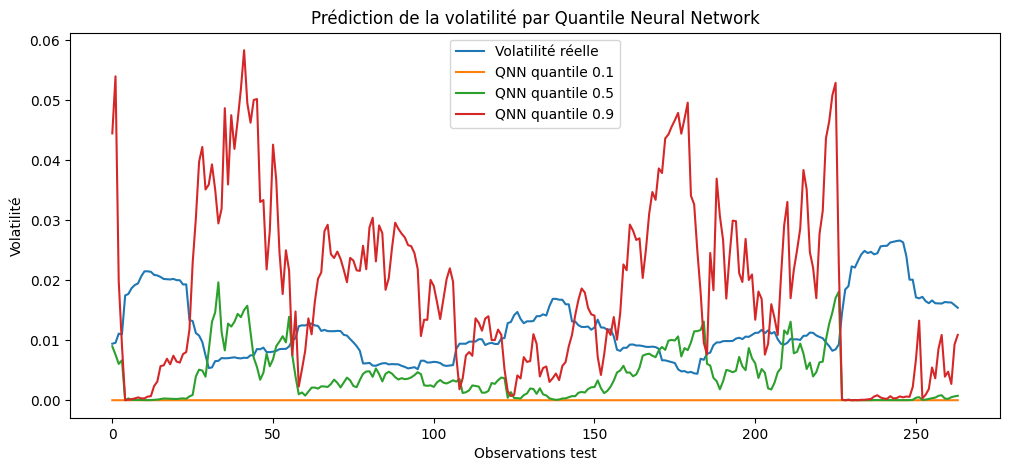

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Volatilité réelle")
plt.plot(predictions[0.1], label="QNN quantile 0.1")
plt.plot(predictions[0.5], label="QNN quantile 0.5")
plt.plot(predictions[0.9], label="QNN quantile 0.9")

plt.title("Prédiction de la volatilité par Quantile Neural Network")
plt.xlabel("Observations test")
plt.ylabel("Volatilité")
plt.legend()
plt.show()

In [13]:
import shap

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
model_shap = models[0.9]

X_train_shap = X_train_scaled[:100]
X_test_shap = X_test_scaled[:100]

In [15]:
explainer = shap.KernelExplainer(
    model_shap.predict,
    X_train_shap
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [16]:
shap_values = explainer.shap_values(X_test_shap)

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


  1%|          | 1/100 [00:08<14:22,  8.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


  2%|▏         | 2/100 [00:16<13:26,  8.23s/it]

...

 98%|█████████▊| 98/100 [13:55<00:16,  8.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


 99%|█████████▉| 99/100 [14:03<00:08,  8.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


100%|██████████| 100/100 [14:12<00:00,  8.52s/it]


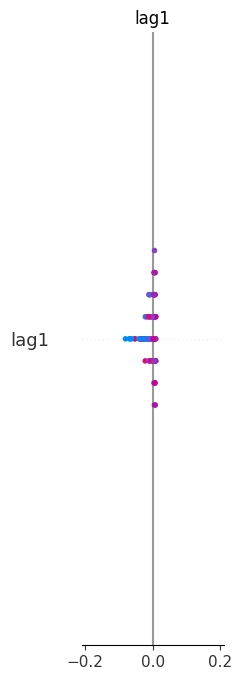

In [17]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_cols
)

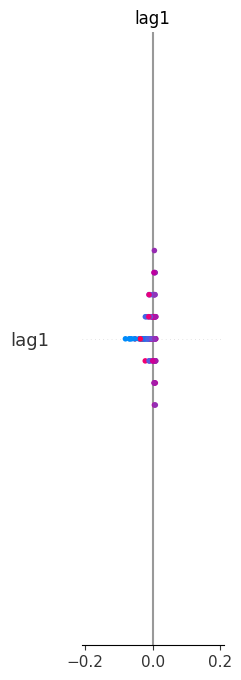

In [18]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_cols,
    plot_type="bar"
)


In [21]:
resultats_df.to_excel("resultats_qnn.xlsx", index=False)

In [22]:
df_predictions = pd.DataFrame({
    "volatilite_reelle": y_test.values,
    "qnn_0_1": predictions[0.1],
    "qnn_0_5": predictions[0.5],
    "qnn_0_9": predictions[0.9]
})

df_predictions.to_excel("predictions_qnn.xlsx", index=False)